# Use GMM to generate New Handwritten Digits

GMM, a generative model of data, can be used to create new samples from the distribution defined by the input data


## Load digits


In [1]:
from sklearn.datasets import load_digits

digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [2]:
digits.data.shape

(1797, 64)

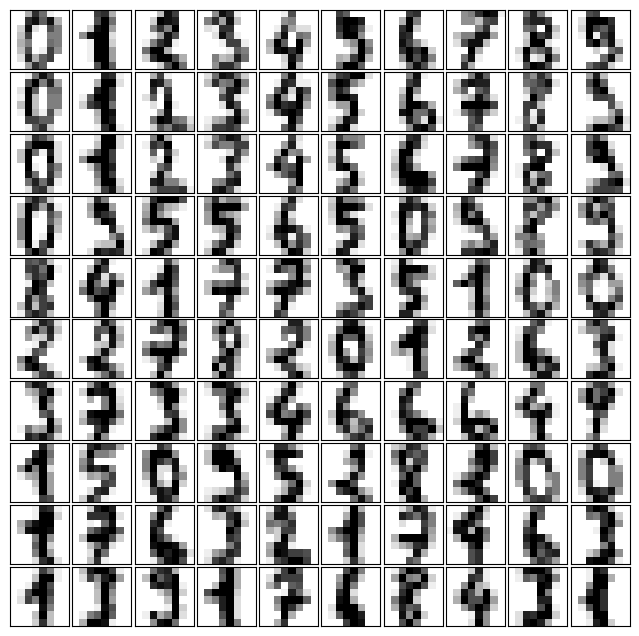

In [3]:
import matplotlib.pyplot as plt


def plot_digits(data):
    fig, ax = plt.subplots(
        10, 10, figsize=(8, 8), subplot_kw=dict(xticks=[], yticks=[])
    )
    fig.subplots_adjust(hspace=0.05, wspace=0.05)
    for i, axi in enumerate(ax.flat):
        im = axi.imshow(data[i].reshape(8, 8), cmap="binary")
        im.set_clim(0, 16)


plot_digits(digits.data)

## Reduce dimension

GMMs can have difficulty converging in such a high dimensional space, so lets start with an invertible dimensionality reduction algorithm on the data


In [4]:
from sklearn.decomposition import PCA

pca = PCA(0.99, whiten=True)
data = pca.fit_transform(digits.data)
data.shape

(1797, 41)

## GMM

- get optimal number of components
- fit GMM
- inverse transform data


In [9]:
import numpy as np
from sklearn.mixture import GaussianMixture

CPU times: user 1min 9s, sys: 14.6 s, total: 1min 24s
Wall time: 11.2 s


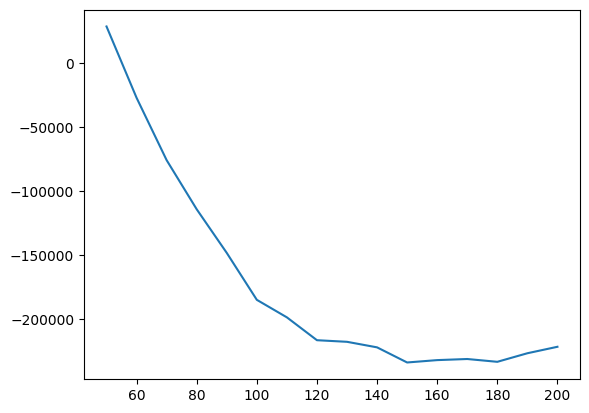

In [10]:
%%time
n_components = np.arange(50, 210, 10)
models = [
    GaussianMixture(n, covariance_type="full", random_state=0) for n in n_components
]
aics = [model.fit(data).aic(data) for model in models]
plt.plot(n_components, aics)

In [11]:
gmm = GaussianMixture(150, covariance_type="full", random_state=0)
gmm.fit(data)
gmm.converged_

True

In [16]:
data_new, _l = gmm.sample(100)
data_new.shape

(100, 41)

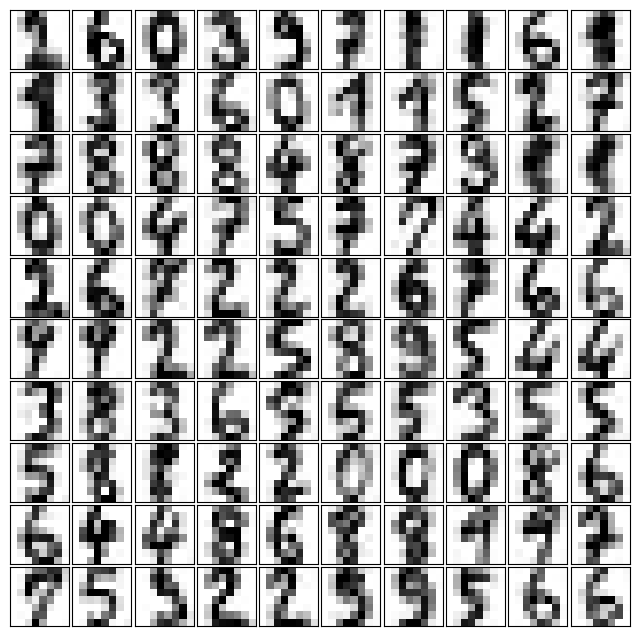

In [17]:
digits_new = pca.inverse_transform(data_new)
plot_digits(digits_new)

> Conclusion:
> we have modeled the distribution of that data in such a way that we can generate brand new samples of digits from the data
